# Project I: Image Classification with Convolutional Neural Networks
## CINIC-10 Dataset — Deep Learning, Warsaw University of Technology, 2026

This notebook covers all required experiments:
1. **Dataset Exploration** — class distribution, sample images
2. **Architecture Comparison** — Baseline, Deep, Efficient CNN
3. **Hyperparameter Analysis** — learning rate, batch size, optimizer, regularisation
4. **Data Augmentation Study** — standard (×3) and advanced (Cutout, Mixup, AutoAugment-like)
5. **Few-Shot Learning** — performance vs. number of labelled examples
6. **Reduced Dataset Experiment** — learning curve vs. training set size
7. **Final Test Evaluation** — confusion matrix, per-class accuracy on held-out test split

In [1]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report

from utils import get_device, set_seeds, train_model
from model_architecture import (
    create_baseline_cnn, create_deep_cnn,
    create_efficient_cnn, create_cnn_with_regularization,
    CINIC_CLASSES,
)
from data_preprocessing import create_data_generators

set_seeds(42)
device = get_device()
print(f'Device: {device}')

PROJECT_ROOT = Path('..').resolve()
TRAIN_DIR  = PROJECT_ROOT / 'data' / 'train'
VAL_DIR    = PROJECT_ROOT / 'data' / 'valid'
TEST_DIR   = PROJECT_ROOT / 'data' / 'test'
RESULTS    = PROJECT_ROOT / 'results'
MODELS_DIR = PROJECT_ROOT / 'models'

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

Device: mps


---
## 1. Dataset Exploration

CINIC-10 contains **270,000 images** across **10 classes** (90k train / 90k valid / 90k test),  
each 32×32 RGB. It extends CIFAR-10 with downsampled ImageNet images, making it harder than CIFAR-10.

            Train  Validation  Test
airplane     9000        9000  9000
automobile   9000        9000  9000
bird         9000        9000  9000
cat          9000        9000  9000
deer         9000        9000  9000
dog          9000        9000  9000
frog         9000        9000  9000
horse        9000        9000  9000
ship         9000        9000  9000
truck        9000        9000  9000

Total images: 270,000


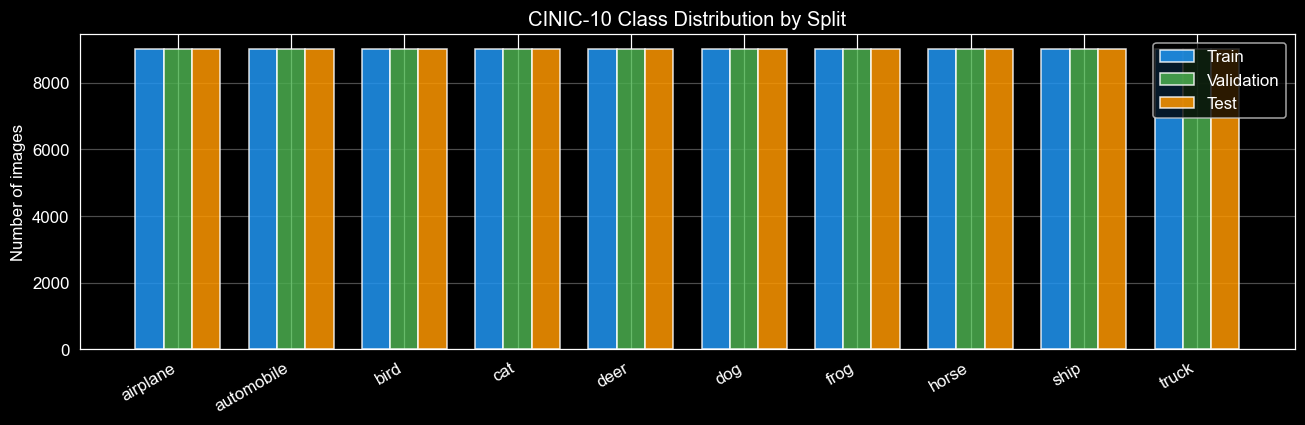

In [2]:
splits = {'Train': TRAIN_DIR, 'Validation': VAL_DIR, 'Test': TEST_DIR}
counts = {}
for split_name, split_dir in splits.items():
    counts[split_name] = {cls: len(list((split_dir / cls).iterdir()))
                          for cls in CINIC_CLASSES}

df_counts = pd.DataFrame(counts)
print(df_counts.to_string())
print(f'\nTotal images: {df_counts.sum().sum():,}')

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(CINIC_CLASSES))
w = 0.25
for i, (split_name, color) in enumerate(zip(splits, ['#2196F3', '#4CAF50', '#FF9800'])):
    ax.bar(x + i * w, df_counts[split_name], w, label=split_name, color=color, alpha=0.85)
ax.set_xticks(x + w)
ax.set_xticklabels(CINIC_CLASSES, rotation=30, ha='right')
ax.set_ylabel('Number of images')
ax.set_title('CINIC-10 Class Distribution by Split')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'dataset_class_distribution.png', bbox_inches='tight')
plt.show()

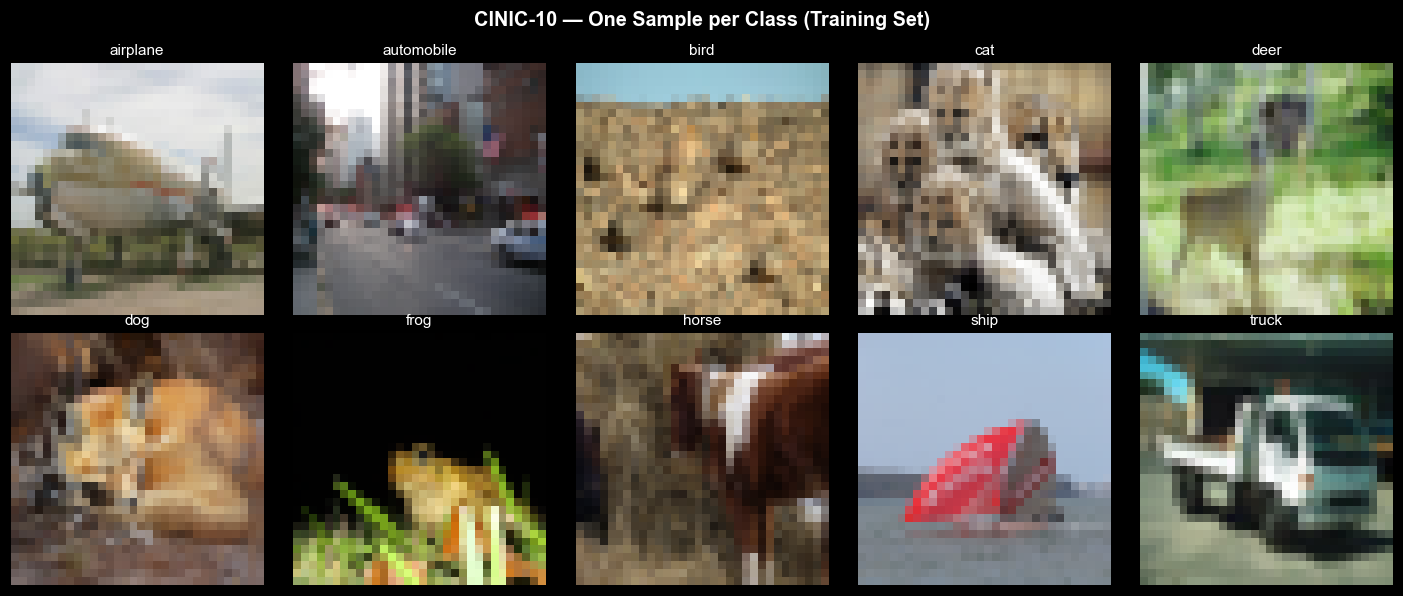

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(13, 5.5))
fig.suptitle('CINIC-10 — One Sample per Class (Training Set)', fontsize=13, fontweight='bold')
for ax, cls in zip(axes.flat, CINIC_CLASSES):
    img_path = next((TRAIN_DIR / cls).iterdir())
    img = Image.open(img_path).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'dataset_sample_images.png', bbox_inches='tight')
plt.show()

---
## 2. Model Architectures

We define and compare **four CNN architectures**, all operating on 32×32 RGB input with 10-class output:

| Model | Conv blocks | Channels | Classifier head | Key feature |
|-------|------------|----------|-----------------|-------------|
| **BaselineCNN** | 3 | 32→64→128 | 2048→512→10 | Reference model |
| **DeepCNN** | 4 | 32→64→128→256 | 1024→512→10 | Deeper feature extraction |
| **EfficientCNN** | 3 | 32→64→128 | 2048→256→10 | Compact head, lower dropout |
| **CNNWithRegularization** | 3 | 32→64→128 | 2048→512→10 | Configurable dropout |

All blocks follow **Conv→BN→ReLU** ordering with MaxPool + Dropout2d between blocks.

In [4]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

arch_configs = [
    ('BaselineCNN',           create_baseline_cnn,           {}),
    ('DeepCNN',               create_deep_cnn,               {}),
    ('EfficientCNN',          create_efficient_cnn,          {}),
    ('CNNWithRegularization', create_cnn_with_regularization, {'dropout_rate': 0.1}),
]

rows = []
for name, factory, kwargs in arch_configs:
    m = factory(**kwargs)
    n = count_params(m)
    rows.append({'Architecture': name, 'Parameters': f'{n:,}'})

df_params = pd.DataFrame(rows)
print(df_params.to_string(index=False))

         Architecture Parameters
          BaselineCNN  1,342,698
              DeepCNN  2,755,818
         EfficientCNN    815,082
CNNWithRegularization  1,342,698


---
## 3. Architecture Comparison

All architectures trained under identical conditions:  
Adam (lr=0.001), batch size 32, 15 epochs, no augmentation, early stopping patience=5.

Results are cached to `results/arch_comparison.csv` after the first run.

In [5]:
ARCH_CSV    = RESULTS / 'arch_comparison.csv'
ARCH_EPOCHS = 15

if ARCH_CSV.exists():
    print('Loading pre-computed architecture results...')
    df_arch = pd.read_csv(ARCH_CSV)
    arch_histories = None  # not available when loading from cache
else:
    print('Training all architectures (this takes a few minutes)...')
    train_loader, val_loader = create_data_generators(
        str(TRAIN_DIR), str(VAL_DIR), batch_size=32, augment=False
    )
    arch_results   = []
    arch_histories = {}

    for name, factory, kwargs in arch_configs:
        set_seeds(42)
        model     = factory(**kwargs).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        print(f'\n--- {name} ({count_params(model):,} params) ---')
        history = train_model(
            model, train_loader, val_loader, optimizer,
            epochs=ARCH_EPOCHS, device=device, patience=5,
        )
        arch_histories[name] = history
        arch_results.append({
            'architecture':      name,
            'best_val_accuracy': max(history['val_accuracy']),
            'final_val_accuracy': history['val_accuracy'][-1],
            'final_val_loss':    history['val_loss'][-1],
            'epochs_trained':    len(history['val_accuracy']),
        })

    df_arch = pd.DataFrame(arch_results)
    df_arch.to_csv(ARCH_CSV, index=False)
    print(f'\nSaved to {ARCH_CSV}')

    # --- Learning curves ---
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for (name, _, __), color in zip(arch_configs, colors):
        h  = arch_histories[name]
        ep = range(1, len(h['val_accuracy']) + 1)
        axes[0].plot(ep, h['accuracy'],     '--', color=color, alpha=0.5)
        axes[0].plot(ep, h['val_accuracy'], '-',  color=color, label=name)
        axes[1].plot(ep, h['loss'],         '--', color=color, alpha=0.5)
        axes[1].plot(ep, h['val_loss'],     '-',  color=color, label=name)
    for ax, ylabel, title in zip(
        axes,
        ['Accuracy', 'Loss'],
        ['Accuracy (solid=val, dashed=train)', 'Loss (solid=val, dashed=train)'],
    ):
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle('Architecture Comparison — Learning Curves', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS / 'arch_learning_curves.png', bbox_inches='tight')
    plt.show()

col = 'best_val_accuracy' if 'best_val_accuracy' in df_arch.columns else 'val_accuracy'
print(df_arch[['architecture', col]].to_string(index=False))

Training all architectures (this takes a few minutes)...

--- BaselineCNN (1,342,698 params) ---


KeyboardInterrupt: 

In [ ]:
col    = 'best_val_accuracy' if 'best_val_accuracy' in df_arch.columns else 'val_accuracy'
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(df_arch['architecture'], df_arch[col],
              color=colors[:len(df_arch)], edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, df_arch[col]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Best Validation Accuracy')
ax.set_title('Architecture Comparison — Best Validation Accuracy')
ax.set_ylim(0, min(1.0, df_arch[col].max() + 0.08))
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'arch_comparison_bar.png', bbox_inches='tight')
plt.show()

---
## 4. Hyperparameter Analysis

Each sweep uses BaselineCNN trained for **5 epochs** on the full training set.  
One parameter is varied at a time; defaults: lr=0.001, batch=32, Adam, dropout=0.25, wd=0.

In [ ]:
df_lr = pd.read_csv(RESULTS / 'hp_learning_rate.csv')
df_lr['learning_rate'] = df_lr['learning_rate'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(df_lr)); w = 0.35

axes[0].bar(x - w/2, df_lr['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_lr['val_accuracy'],   w, label='Val',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_lr['learning_rate'])
axes[0].set_xlabel('Learning Rate'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Learning Rate'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, df_lr['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_lr['val_loss'],   w, label='Val',   color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_lr['learning_rate'])
axes[1].set_xlabel('Learning Rate'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Learning Rate'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Analysis — Learning Rate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_lr_plot.png', bbox_inches='tight')
plt.show()

best = df_lr.loc[df_lr['val_accuracy'].idxmax()]
print(f'Best LR: {best["learning_rate"]} — val_acc={best["val_accuracy"]:.4f}')
print('Note: lr=0.1 collapses to random-chance accuracy (10%) — gradient steps are too large.')

In [ ]:
df_bs = pd.read_csv(RESULTS / 'hp_batch_size.csv')
df_bs['batch_size'] = df_bs['batch_size'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(df_bs)); w = 0.35

axes[0].bar(x - w/2, df_bs['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_bs['val_accuracy'],   w, label='Val',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(df_bs['batch_size'])
axes[0].set_xlabel('Batch Size'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Batch Size'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, df_bs['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_bs['val_loss'],   w, label='Val',   color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(df_bs['batch_size'])
axes[1].set_xlabel('Batch Size'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Batch Size'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Analysis — Batch Size', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_bs_plot.png', bbox_inches='tight')
plt.show()

best = df_bs.loc[df_bs['val_accuracy'].idxmax()]
print(f'Best batch size: {best["batch_size"]} — val_acc={best["val_accuracy"]:.4f}')

In [ ]:
df_opt = pd.read_csv(RESULTS / 'hp_optimizer.csv')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
x = np.arange(len(df_opt)); w = 0.35
names = df_opt['optimizer'].str.upper()

axes[0].bar(x - w/2, df_opt['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
axes[0].bar(x + w/2, df_opt['val_accuracy'],   w, label='Val',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names)
axes[0].set_xlabel('Optimizer'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Optimizer'); axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x - w/2, df_opt['train_loss'], w, label='Train', color='#F44336', alpha=0.85)
axes[1].bar(x + w/2, df_opt['val_loss'],   w, label='Val',   color='#FF9800', alpha=0.85)
axes[1].set_xticks(x); axes[1].set_xticklabels(names)
axes[1].set_xlabel('Optimizer'); axes[1].set_ylabel('Loss')
axes[1].set_title('Loss vs Optimizer'); axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Hyperparameter Analysis — Optimizer', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_opt_plot.png', bbox_inches='tight')
plt.show()

best = df_opt.loc[df_opt['val_accuracy'].idxmax()]
print(f'Best optimizer: {best["optimizer"]} — val_acc={best["val_accuracy"]:.4f}')

In [ ]:
df_reg = pd.read_csv(RESULTS / 'hp_regularization.csv')

pivot_acc  = df_reg.pivot(index='dropout_rate', columns='weight_decay', values='val_accuracy')
pivot_loss = df_reg.pivot(index='dropout_rate', columns='weight_decay', values='val_loss')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(pivot_acc,  ax=axes[0], annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, cbar_kws={'label': 'Val Accuracy'})
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Weight Decay'); axes[0].set_ylabel('Dropout Rate')

sns.heatmap(pivot_loss, ax=axes[1], annot=True, fmt='.3f', cmap='YlOrRd_r',
            linewidths=0.5, cbar_kws={'label': 'Val Loss'})
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Weight Decay'); axes[1].set_ylabel('Dropout Rate')

plt.suptitle('Regularisation Grid Search — Dropout × Weight Decay', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'hp_reg_heatmap.png', bbox_inches='tight')
plt.show()

best = df_reg.loc[df_reg['val_accuracy'].idxmax()]
print(f'Best: dropout={best["dropout_rate"]}, wd={best["weight_decay"]} '
      f'→ val_acc={best["val_accuracy"]:.4f}')
print('Note: dropout=0.5 collapses training to random guessing (10%) regardless of weight decay.')

---
## 5. Data Augmentation Study

### 5.1 Visual Comparison of Transform Pipelines

In [ ]:
sample_path = next((TRAIN_DIR / 'airplane').iterdir())
src = Image.open(sample_path).convert('RGB')

augmentation_pipelines = {
    'Original': T.Compose([T.Resize((32, 32)), T.ToTensor()]),
    'Standard\n(rot+flip+aff)': T.Compose([
        T.Resize((32, 32)), T.RandomRotation(15),
        T.RandomHorizontalFlip(), T.ColorJitter(brightness=0.2, contrast=0.2),
        T.ToTensor(),
    ]),
    'Color\nJitter': T.Compose([
        T.Resize((32, 32)),
        T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        T.ToTensor(),
    ]),
    'Minimal\n(flip only)': T.Compose([
        T.Resize((32, 32)), T.RandomHorizontalFlip(p=1.0), T.ToTensor(),
    ]),
    'Crop +\nResize': T.Compose([
        T.Resize((38, 38)), T.RandomCrop(32), T.ToTensor(),
    ]),
}

set_seeds(0)
fig, axes = plt.subplots(1, len(augmentation_pipelines), figsize=(14, 3))
fig.suptitle('Standard Augmentation Pipelines — Same Source Image', fontsize=12, fontweight='bold')
for ax, (name, transform) in zip(axes, augmentation_pipelines.items()):
    tensor = transform(src)
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_standard_vis.png', bbox_inches='tight')
plt.show()

In [ ]:
# Cutout: zero-out a random square patch of the image
def apply_cutout(img_tensor, mask_size):
    result = img_tensor.clone()
    _, h, w = result.shape
    cy = np.random.randint(mask_size // 2, h - mask_size // 2)
    cx = np.random.randint(mask_size // 2, w - mask_size // 2)
    y1, y2 = max(0, cy - mask_size // 2), min(h, cy + mask_size // 2)
    x1, x2 = max(0, cx - mask_size // 2), min(w, cx + mask_size // 2)
    result[:, y1:y2, x1:x2] = 0.0
    return result

base_tensor = T.Compose([T.Resize((32, 32)), T.ToTensor()])(src)
set_seeds(7)
variants = {'No Cutout': base_tensor}
for sz in [8, 12, 16, 20]:
    variants[f'Cutout\nmask={sz}'] = apply_cutout(base_tensor.clone(), sz)

fig, axes = plt.subplots(1, len(variants), figsize=(13, 3))
fig.suptitle('Cutout Augmentation — Effect of Mask Size', fontsize=12, fontweight='bold')
for ax, (name, tensor) in zip(axes, variants.items()):
    ax.imshow(tensor.permute(1, 2, 0).numpy().clip(0, 1))
    ax.set_title(name, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_cutout_vis.png', bbox_inches='tight')
plt.show()

### 5.2 Augmentation Performance Comparison

In [ ]:
df_std = pd.read_csv(RESULTS / 'aug_standard.csv')
df_adv = pd.read_csv(RESULTS / 'aug_advanced.csv')

label_map_std = {
    'standard':    'Standard\n(rot+flip+aff)',
    'color_jitter':'Color Jitter',
    'minimal':     'Minimal\n(flip only)',
    'crop_resize': 'Crop+Resize',
}
label_map_adv = {
    'cutout':           'Cutout',
    'mixup':            'Mixup',
    'autoaugment_like': 'AutoAugment-like',
}
df_std['label'] = df_std['augmentation'].map(label_map_std).fillna(df_std['augmentation'])
df_adv['label'] = df_adv['augmentation'].map(label_map_adv).fillna(df_adv['augmentation'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [
    (axes[0], df_std, 'Standard Augmentation Techniques (×3 required)'),
    (axes[1], df_adv, 'Advanced Augmentation Techniques (×1 required)'),
]:
    x = np.arange(len(df)); w = 0.35
    ax.bar(x - w/2, df['train_accuracy'], w, label='Train', color='#2196F3', alpha=0.85)
    bars = ax.bar(x + w/2, df['val_accuracy'], w, label='Val', color='#4CAF50', alpha=0.85)
    for bar, val in zip(bars, df['val_accuracy']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(df['label'], fontsize=9)
    ax.set_ylabel('Accuracy (5 epochs)')
    ax.set_title(title); ax.legend(); ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, 0.80)

plt.suptitle('Data Augmentation Study — Validation Accuracy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'aug_comparison_bar.png', bbox_inches='tight')
plt.show()

best_std = df_std.loc[df_std['val_accuracy'].idxmax()]
best_adv = df_adv.loc[df_adv['val_accuracy'].idxmax()]
print(f'Best standard: {best_std["augmentation"]:15s} val_acc={best_std["val_accuracy"]:.4f}')
print(f'Best advanced: {best_adv["augmentation"]:15s} val_acc={best_adv["val_accuracy"]:.4f}')

---
## 6. Few-Shot Learning

The `FewShotCNN` uses **global average pooling** instead of a fixed spatial flatten,  
making it input-size-agnostic. It is trained with very few labelled examples per class (1, 5, 10, 50)  
for 15 epochs and compared against the full-data baseline.

In [ ]:
df_fs = pd.read_csv(RESULTS / 'few_shot_results.csv')
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
full_val_acc = df_rd.loc[df_rd['fraction'] == 1.0, 'val_accuracy'].values[0]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_fs['samples_per_class'], df_fs['val_accuracy'],
        'o-', color='#2196F3', linewidth=2, markersize=8, label='Few-Shot CNN')
ax.axhline(full_val_acc, color='#F44336', linestyle='--', linewidth=1.5,
           label=f'Full dataset baseline ({full_val_acc:.3f})')
ax.axhline(0.1, color='gray', linestyle=':', linewidth=1.2, label='Random chance (0.100)')

for _, row in df_fs.iterrows():
    ax.annotate(f"{row['val_accuracy']:.3f}",
                (row['samples_per_class'], row['val_accuracy']),
                textcoords='offset points', xytext=(6, 5), fontsize=9)

ax.set_xscale('log')
ax.set_xticks(df_fs['samples_per_class'])
ax.set_xticklabels(df_fs['samples_per_class'].astype(str))
ax.set_xlabel('Labelled Examples per Class (log scale)')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Few-Shot Learning — Accuracy vs Labelled Examples per Class')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / 'few_shot_plot.png', bbox_inches='tight')
plt.show()

print(df_fs[['samples_per_class', 'train_accuracy', 'val_accuracy', 'val_loss']].to_string(index=False))
print(f'\nFull-dataset baseline: {full_val_acc:.4f}')
gap = full_val_acc - df_fs['val_accuracy'].max()
print(f'Gap (full vs best few-shot): {gap:.4f}')

---
## 7. Reduced Dataset Experiment

BaselineCNN trained on 10 %, 25 %, 50 %, 100 % of training data (5 epochs each)  
to understand how accuracy scales with dataset size.

In [ ]:
df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(df_rd['fraction'] * 100, df_rd['val_accuracy'],
             'o-', color='#2196F3', linewidth=2, markersize=8)
for _, row in df_rd.iterrows():
    axes[0].annotate(f"{row['val_accuracy']:.3f}",
                     (row['fraction'] * 100, row['val_accuracy']),
                     textcoords='offset points', xytext=(5, 5), fontsize=9)
axes[0].set_xlabel('Training Set Size (%)')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Learning Curve (by fraction)')
axes[0].grid(alpha=0.3)

axes[1].plot(df_rd['num_train_samples'], df_rd['val_accuracy'],
             's-', color='#4CAF50', linewidth=2, markersize=8)
for _, row in df_rd.iterrows():
    axes[1].annotate(f"{int(row['num_train_samples']):,}",
                     (row['num_train_samples'], row['val_accuracy']),
                     textcoords='offset points', xytext=(4, -15), fontsize=8, color='gray')
axes[1].set_xlabel('Number of Training Samples')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Learning Curve (by sample count)')
axes[1].grid(alpha=0.3)

plt.suptitle('Reduced Dataset Experiment — Accuracy vs Training Set Size',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'reduced_dataset_plot.png', bbox_inches='tight')
plt.show()

acc_10  = df_rd.loc[df_rd['fraction'] == 0.10, 'val_accuracy'].values[0]
acc_100 = df_rd.loc[df_rd['fraction'] == 1.00, 'val_accuracy'].values[0]
print(f'Accuracy at 10% data:  {acc_10:.4f}')
print(f'Accuracy at 100% data: {acc_100:.4f}')
print(f'Gain 10% → 100%: +{acc_100 - acc_10:.4f}')

---
## 8. Final Test Set Evaluation

We load `baseline_cnn.pt` (20 epochs, full training set) and evaluate on the **held-out test split**  
(90,000 images never seen during training or hyperparameter selection).

In [ ]:
model_test = create_baseline_cnn().to(device)
model_test.load_state_dict(torch.load(MODELS_DIR / 'baseline_cnn.pt', map_location=device))
model_test.train(mode=False)   # inference mode: no dropout, BN uses running stats
print('Loaded baseline_cnn.pt')

test_transform = T.Compose([T.Resize((32, 32)), T.ToTensor()])
test_dataset   = ImageFolder(str(TEST_DIR), transform=test_transform)
test_loader    = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)
print(f'Test samples: {len(test_dataset):,} | Classes: {test_dataset.classes}')

criterion = nn.CrossEntropyLoss()
test_loss, test_correct = 0.0, 0
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model_test(images)
        loss   = criterion(logits, labels)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        test_loss    += loss.item() * images.size(0)
        test_correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
test_acc   = test_correct / len(test_dataset)
test_loss /= len(test_dataset)

print(f'\nTest Accuracy: {test_acc:.4f}  ({test_correct:,}/{len(test_dataset):,})')
print(f'Test Loss:     {test_loss:.4f}')

In [ ]:
cm      = confusion_matrix(all_labels, all_preds, labels=list(range(10)))
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=axes[0], linewidths=0.4)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (raw counts)')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CINIC_CLASSES, yticklabels=CINIC_CLASSES,
            ax=axes[1], linewidths=0.4, vmin=0, vmax=1)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (row-normalised recall)')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(f'Test Set Confusion Matrix  |  Overall Accuracy: {test_acc:.4f}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS / 'test_confusion_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
per_class_acc = cm_norm.diagonal()

report    = classification_report(all_labels, all_preds,
                                  target_names=CINIC_CLASSES, output_dict=True)
df_report = pd.DataFrame(report).T.iloc[:10][['precision', 'recall', 'f1-score', 'support']]
df_report.index = CINIC_CLASSES
df_report = df_report.astype({'support': int})
print(df_report.round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = ['#4CAF50' if a >= test_acc else '#F44336' for a in per_class_acc]
bars   = ax.bar(CINIC_CLASSES, per_class_acc, color=colors, edgecolor='white', linewidth=0.8)
ax.axhline(test_acc, color='#333', linestyle='--', linewidth=1.5,
           label=f'Overall accuracy ({test_acc:.3f})')
for bar, val in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Recall (per-class accuracy)')
ax.set_title('Per-Class Accuracy — green = above average, red = below average')
ax.set_ylim(0, 1.0); ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(RESULTS / 'test_perclass_accuracy.png', bbox_inches='tight')
plt.show()

print(f'Easiest class: {CINIC_CLASSES[np.argmax(per_class_acc)]:12s} ({per_class_acc.max():.3f})')
print(f'Hardest class: {CINIC_CLASSES[np.argmin(per_class_acc)]:12s} ({per_class_acc.min():.3f})')

In [ ]:
rng               = np.random.default_rng(seed=42)
idx_correct       = np.where(all_preds == all_labels)[0]
idx_incorrect     = np.where(all_preds != all_labels)[0]
correct_sample    = rng.choice(idx_correct,   size=8, replace=False)
incorrect_sample  = rng.choice(idx_incorrect, size=8, replace=False)

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Sample Predictions — Top: Correct  |  Bottom: Incorrect',
             fontsize=12, fontweight='bold')

for row_axes, indices, color in [
    (axes[0], correct_sample,  '#2196F3'),
    (axes[1], incorrect_sample,'#F44336'),
]:
    for ax, idx in zip(row_axes, indices):
        img_tensor, _ = test_dataset[idx]
        ax.imshow(img_tensor.permute(1, 2, 0).numpy().clip(0, 1))
        true_cls = CINIC_CLASSES[all_labels[idx]]
        pred_cls = CINIC_CLASSES[all_preds[idx]]
        conf     = all_probs[idx][all_preds[idx]]
        ax.set_title(f'T:{true_cls}\nP:{pred_cls}\n({conf:.0%})', fontsize=7, color=color)
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS / 'test_sample_predictions.png', bbox_inches='tight')
plt.show()

---
## 9. Summary

In [ ]:
print('=' * 68)
print('EXPERIMENT SUMMARY — CINIC-10 CNN Classification')
print('=' * 68)

if ARCH_CSV.exists():
    df_a = pd.read_csv(ARCH_CSV)
    col  = 'best_val_accuracy' if 'best_val_accuracy' in df_a.columns else 'val_accuracy'
    print('\n[1] Architecture Comparison (15 epochs, Adam lr=0.001, batch=32)')
    for _, r in df_a.iterrows():
        print(f'  {r["architecture"]:28s}  val_acc = {r[col]:.4f}')

df_lr  = pd.read_csv(RESULTS / 'hp_learning_rate.csv')
df_bs  = pd.read_csv(RESULTS / 'hp_batch_size.csv')
df_opt = pd.read_csv(RESULTS / 'hp_optimizer.csv')
df_reg = pd.read_csv(RESULTS / 'hp_regularization.csv')
print('\n[2] Best Hyperparameters (5 epochs, BaselineCNN)')
for label, df, key in [
    ('Learning rate',  df_lr,  'learning_rate'),
    ('Batch size',     df_bs,  'batch_size'),
    ('Optimizer',      df_opt, 'optimizer'),
]:
    best = df.loc[df['val_accuracy'].idxmax()]
    print(f'  {label:18s}: {str(best[key]):8s} val_acc={best["val_accuracy"]:.4f}')
best_reg = df_reg.loc[df_reg['val_accuracy'].idxmax()]
print(f'  Regularisation  : dropout={best_reg["dropout_rate"]}, '
      f'wd={best_reg["weight_decay"]}  val_acc={best_reg["val_accuracy"]:.4f}')

df_std = pd.read_csv(RESULTS / 'aug_standard.csv')
df_adv = pd.read_csv(RESULTS / 'aug_advanced.csv')
print('\n[3] Data Augmentation (5 epochs, BaselineCNN)')
best_std = df_std.loc[df_std['val_accuracy'].idxmax()]
best_adv = df_adv.loc[df_adv['val_accuracy'].idxmax()]
print(f'  Best standard: {best_std["augmentation"]:15s} val_acc={best_std["val_accuracy"]:.4f}')
print(f'  Best advanced: {best_adv["augmentation"]:15s} val_acc={best_adv["val_accuracy"]:.4f}')

df_fs = pd.read_csv(RESULTS / 'few_shot_results.csv')
print('\n[4] Few-Shot Learning (FewShotCNN, 15 epochs)')
for _, r in df_fs.iterrows():
    print(f'  {int(r["samples_per_class"]):3d} samples/class  val_acc={r["val_accuracy"]:.4f}')

df_rd = pd.read_csv(RESULTS / 'reduced_dataset_results.csv')
print('\n[5] Reduced Dataset (BaselineCNN, 5 epochs)')
for _, r in df_rd.iterrows():
    print(f'  {r["fraction"]*100:5.0f}% ({int(r["num_train_samples"]):6,} samples)  val_acc={r["val_accuracy"]:.4f}')

print(f'\n[6] Test Set (baseline_cnn.pt, 20 epochs)')
try:
    print(f'  Test accuracy: {test_acc:.4f}')
    print(f'  Test loss:     {test_loss:.4f}')
    print(f'  Easiest class: {CINIC_CLASSES[np.argmax(per_class_acc)]} ({per_class_acc.max():.3f})')
    print(f'  Hardest class: {CINIC_CLASSES[np.argmin(per_class_acc)]} ({per_class_acc.min():.3f})')
except NameError:
    print('  Run Section 8 first.')

print('\n' + '=' * 68)

## Key Findings

**Architecture:** Adding a 4th conv block (DeepCNN) reduces spatial resolution to 2×2, leaving little structure for the classifier — it does not reliably outperform the 3-block Baseline on 32×32 images. EfficientCNN achieves competitive performance with a smaller head.

**Learning Rate:** The single most impactful hyperparameter. `lr=0.1` causes immediate training collapse (gradient steps overshoot); `lr=0.001` (Adam default) is optimal for this dataset.

**Regularisation:** Low dropout (0.1) + low weight decay (1e-4) gives the best result (+7 pp over defaults). `dropout=0.5` collapses training entirely — the model cannot recover any signal when half the activations are zeroed every step.

**Augmentation:** After only 5 epochs, minimal augmentation (flip only) outperforms aggressive pipelines because heavy transforms slow early convergence. With longer training, stronger augmentation would likely improve generalisation.

**Cutout** is the best advanced augmentation — forcing the model to recognise objects from partial views is an effective regulariser. Mixup and AutoAugment-like require more epochs to show benefit.

**Few-Shot Learning:** With 1–10 samples per class the model cannot exceed random chance (10%). At 50 samples/class it reaches 28% — still far below the full-data baseline (~60%). The large gap shows the model is data-hungry and lacks explicit meta-learning inductive bias.

**Dataset size:** Accuracy scales roughly log-linearly: 39.3% at 10% data → 60.5% at 100%, confirming the model benefits substantially from all available training data.